Risk Tier Classifier—Random forest: predict High/Medium/Low from 8 features (Val, ton, seaport miles, neighbor distance, commodity mix, metro flag). uses leave one out CV (n=134)

In [1]:
import pandas as pd
import numpy as np

In [4]:
features = pd.read_csv('features_master(in).csv')
distmat = pd.read_csv('distance_matrix(in).csv')
port = pd.read_csv('port_proximity(in).csv')

In [5]:
print(features.shape)
print(distmat.shape)
print(port.shape)

(134, 21)
(17822, 5)
(134, 7)


In [6]:
print(features.columns)
print(distmat.columns)
print(port.columns)

Index(['GEO_ID', 'NAME', 'VAL', 'TON', 'val_norm', 'ton_norm',
       'vulnerability_score', 'rank', 'is_metro', 'INTPTLAT', 'INTPTLON',
       'nearest_port', 'nearest_port_type', 'nearest_port_miles',
       'nearest_seaport', 'nearest_seaport_miles',
       'min_distance_to_neighbor_miles', 'num_commodities', 'max_comm_val',
       'dominant_commodity', 'val_ton_ratio'],
      dtype='object')
Index(['GEO_ID_origin', 'NAME_origin', 'GEO_ID_dest', 'NAME_dest',
       'distance_miles'],
      dtype='object')
Index(['GEO_ID', 'NAME', 'nearest_port', 'nearest_port_type',
       'nearest_port_miles', 'nearest_seaport', 'nearest_seaport_miles'],
      dtype='object')


In [17]:
p90 = features['vulnerability_score'].quantile(.90)
p75 = features['vulnerability_score'].quantile(.75)

In [19]:
features['risk_tier'] = 'Low'
features.loc[features['vulnerability_score'] >= p75, 'risk_tier'] = 'Medium'
features.loc[features['vulnerability_score'] >= p90, 'risk_tier'] = 'High'
print(features['risk_tier'].value_counts())

risk_tier
Low       100
Medium     20
High       14
Name: count, dtype: int64


In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
features['dominant_commodity'] = le.fit_transform(features['dominant_commodity'])

In [24]:
y = features['risk_tier']
X = features[['VAL',
              'TON',
              'nearest_seaport_miles',
              'min_distance_to_neighbor_miles',
              'num_commodities',
              'dominant_commodity',
              'val_ton_ratio',
              'is_metro']]

In [25]:
print(X.shape)
print(y.shape)

(134, 8)
(134,)


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut

rf = RandomForestClassifier( class_weight= 'balanced')
loo = LeaveOneOut()

In [30]:
predictions = []

for train_idx, test_idx in loo.split(X, y):
  X_train = X.iloc[train_idx]
  X_test = X.iloc[test_idx]
  y_train = y.iloc[train_idx]
  rf.fit(X_train, y_train)
  pred = rf.predict(X_test)
  predictions.append(pred)

In [31]:
print(len(predictions))

134


In [32]:
import numpy as np
predictions_flat = np.concatenate(predictions)

In [34]:
from sklearn.metrics import accuracy_score
accuracy_score (y, predictions_flat)

0.9029850746268657

In [35]:
from sklearn.metrics import classification_report
print(classification_report(y, predictions_flat))

              precision    recall  f1-score   support

        High       0.80      0.86      0.83        14
         Low       0.94      0.98      0.96       100
      Medium       0.73      0.55      0.63        20

    accuracy                           0.90       134
   macro avg       0.83      0.80      0.81       134
weighted avg       0.90      0.90      0.90       134



In [36]:
rf.fit(X, y)
importance = pd.Series(rf.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

TON                               0.326417
VAL                               0.284712
num_commodities                   0.186659
val_ton_ratio                     0.076115
nearest_seaport_miles             0.065468
min_distance_to_neighbor_miles    0.041889
is_metro                          0.018740
dominant_commodity                0.000000
dtype: float64


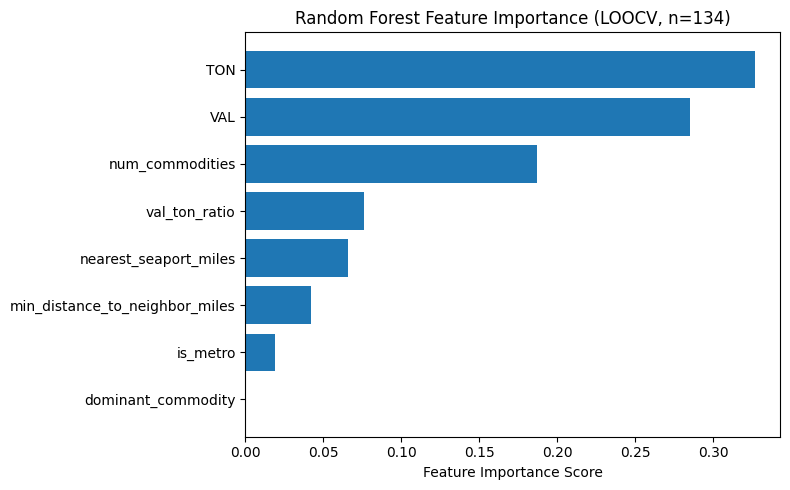

In [39]:
import matplotlib.pyplot as plt

importance_sorted = importance.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_sorted.index, importance_sorted.values)
plt.xlabel('Feature Importance Score')
plt.title('Random Forest Feature Importance (LOOCV, n=134)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
risk_tier_table = features[['GEO_ID', 'NAME', 'VAL', 'TON', 'vulnerability_score', 'risk_tier']].copy()
risk_tier_table['predicted_tier'] = predictions_flat
risk_tier_table = risk_tier_table.sort_values('vulnerability_score', ascending=False)

risk_tier_table.to_csv('risk_tier_output.csv', index=False)
print(risk_tier_table.head(20))

                 GEO_ID                                               NAME  \
0   E330000US0634800000    Los Angeles-Long Beach, CA CFS Area; California   
1   E330000US4828800000          Houston-The Woodlands, TX CFS Area; Texas   
2   E330000US1717600000  Chicago-Naperville, IL-IN-WI CFS Area (part); ...   
3   E330000US4820600000    Dallas-Fort Worth, TX-OK CFS Area (part); Texas   
4   E330000US4899999999                          Remainder of Texas, Texas   
5   E330000US1799999999                    Remainder of Illinois, Illinois   
6   E330000US4299999999            Remainder of Pennsylvania, Pennsylvania   
7   E330000US0648800000  San Jose-San Francisco-Oakland, CA CFS Area; C...   
8   E330000US1312200000  Atlanta--Athens-Clarke County--Sandy Springs, ...   
9   E330000US5599999999                  Remainder of Wisconsin, Wisconsin   
10  E330000US3440800000  New York-Newark, NY-NJ-CT-PA CFS Area (part); ...   
11  E330000US1899999999                      Remainder of Indian